# LAPTOP PRICE PREDICTION DATA PREPROCESSING

# Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

# Loading Data

In [2]:
raw_data = pd.read_csv('laptop_price_dataset.csv')
raw_data.head()

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price
0,MSI,16.0,256.0,3.72,17.0,New,2019.0,1337.45
1,Asus,16.0,512.0,2.05,14.0,Used,2022.0,922.01
2,Acer,4.0,2048.0,3.36,14.0,Used,2020.0,1301.30
3,MSI,8.0,256.0,2.81,15.6,New,2020.0,1014.26
4,Samsung,16.0,1024.0,3.50,13.3,New,NaN,1644.02


In [3]:
data=raw_data.copy()
data.head()

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price
0,MSI,16.0,256.0,3.72,17.0,New,2019.0,1337.45
1,Asus,16.0,512.0,2.05,14.0,Used,2022.0,922.01
2,Acer,4.0,2048.0,3.36,14.0,Used,2020.0,1301.30
3,MSI,8.0,256.0,2.81,15.6,New,2020.0,1014.26
4,Samsung,16.0,1024.0,3.50,13.3,New,NaN,1644.02


# Preprocessing

## Exploring the descriptive statistics of the variables

In [4]:
data.describe(include='all')

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price
count,956,939.000000,948.000000,941.000000,944.000000,961,948.000000,1000.000000
unique,8,NaN,NaN,NaN,NaN,3,NaN,NaN
top,Dell,NaN,NaN,NaN,NaN,Used,NaN,NaN
freq,147,NaN,NaN,NaN,NaN,438,NaN,NaN
mean,NaN,16.984026,556.962025,3.094857,15.186547,NaN,2020.505274,1331.351230
std,NaN,13.999801,461.079788,0.636703,1.352590,NaN,2.254404,491.609447
min,NaN,4.000000,128.000000,2.000000,13.300000,NaN,2017.000000,480.000000
25%,NaN,8.000000,256.000000,2.540000,14.000000,NaN,2019.000000,993.275000
50%,NaN,16.000000,512.000000,3.090000,15.600000,NaN,2021.000000,1219.135000
75%,NaN,16.000000,512.000000,3.650000,16.000000,NaN,2022.250000,1562.447500


## Dealing with missing values

In [5]:
data.isnull().sum()

Brand              44
RAM                61
Storage            52
Processor_Speed    59
Screen_Size        56
Condition          39
Year               52
Price               0
dtype: int64

In [6]:
data["Brand"].fillna(data["Brand"].mode()[0], inplace=True)

In [7]:
data["RAM"].fillna(data["RAM"].median(), inplace=True)

In [8]:
data["Storage"].fillna(data["Storage"].median(), inplace=True)

In [9]:
data["Processor_Speed"].fillna(data["Processor_Speed"].mean(), inplace=True)

In [10]:
data["Screen_Size"].fillna(data["Screen_Size"].median(), inplace=True)

In [11]:
data["Condition"].fillna(data["Condition"].mode()[0], inplace=True)

In [12]:
data["Year"].fillna(data["Year"].median(), inplace=True)

In [13]:
data.describe(include='all')

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price
count,1000,1000.000000,1000.000000,1000.000000,1000.00000,1000,1000.000000,1000.000000
unique,8,NaN,NaN,NaN,NaN,3,NaN,NaN
top,Dell,NaN,NaN,NaN,NaN,Used,NaN,NaN
freq,191,NaN,NaN,NaN,NaN,477,NaN,NaN
mean,NaN,16.924000,554.624000,3.094857,15.20970,NaN,2020.531000,1331.351230
std,NaN,13.567693,449.030448,0.617616,1.31757,NaN,2.197696,491.609447
min,NaN,4.000000,128.000000,2.000000,13.30000,NaN,2017.000000,480.000000
25%,NaN,8.000000,256.000000,2.560000,14.00000,NaN,2019.000000,993.275000
50%,NaN,16.000000,512.000000,3.094857,15.60000,NaN,2021.000000,1219.135000
75%,NaN,16.000000,512.000000,3.620000,16.00000,NaN,2022.000000,1562.447500


In [14]:
data_withno_mvs=data.copy()

In [15]:
data_withno_mvs.head()

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price
0,MSI,16.0,256.0,3.72,17.0,New,2019.0,1337.45
1,Asus,16.0,512.0,2.05,14.0,Used,2022.0,922.01
2,Acer,4.0,2048.0,3.36,14.0,Used,2020.0,1301.30
3,MSI,8.0,256.0,2.81,15.6,New,2020.0,1014.26
4,Samsung,16.0,1024.0,3.50,13.3,New,2021.0,1644.02


## Exploring the PDFs

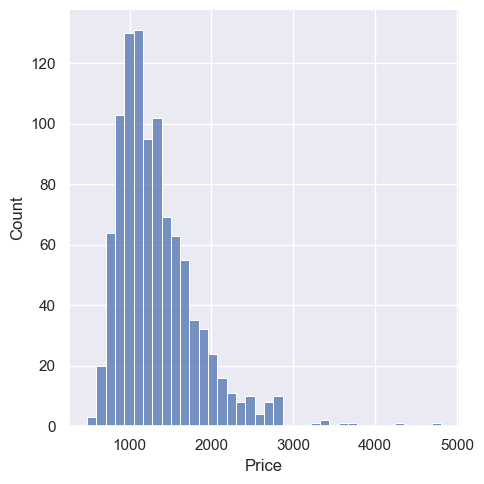

In [16]:
sns.displot(data_withno_mvs['Price'])
plt.show()

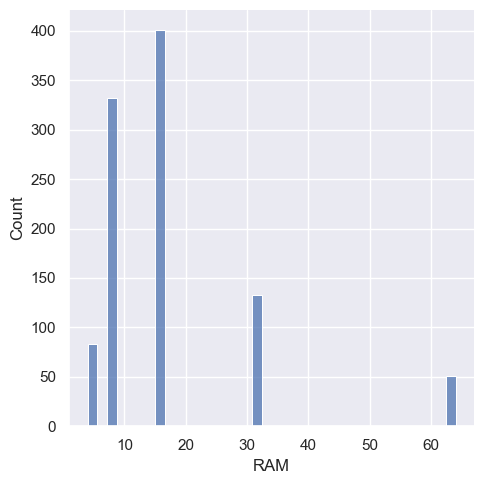

In [17]:
sns.displot(data_withno_mvs['RAM'])
plt.show()

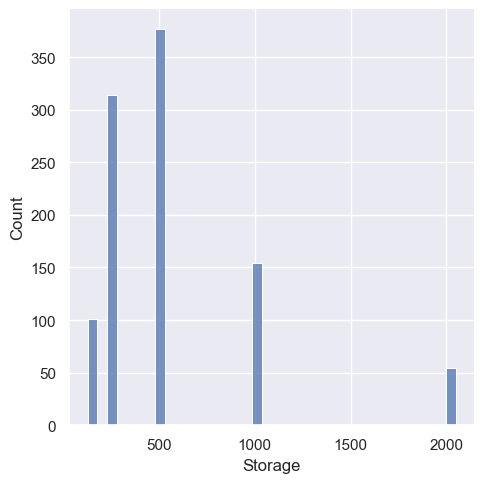

In [18]:
sns.displot(data_withno_mvs['Storage'])
plt.show()

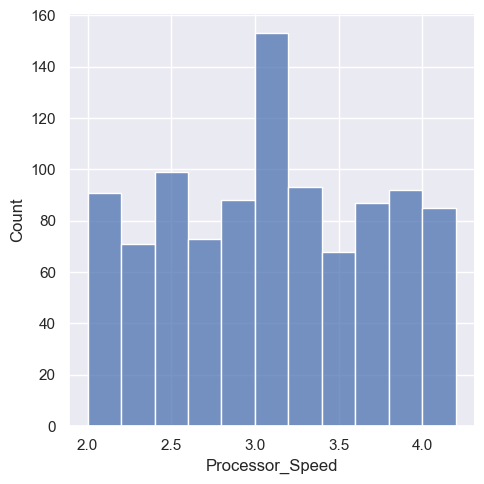

In [19]:
sns.displot(data_withno_mvs['Processor_Speed'])
plt.show()

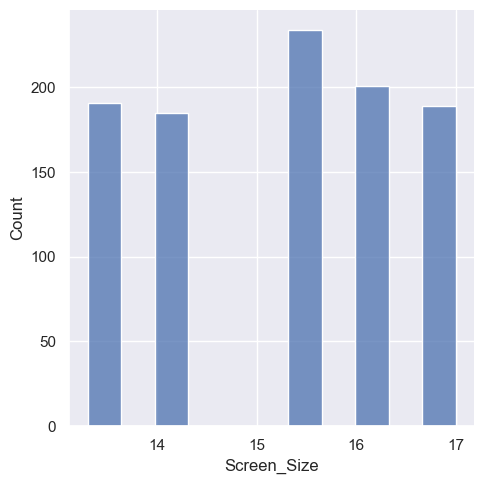

In [20]:
sns.displot(data_withno_mvs['Screen_Size'])
plt.show()

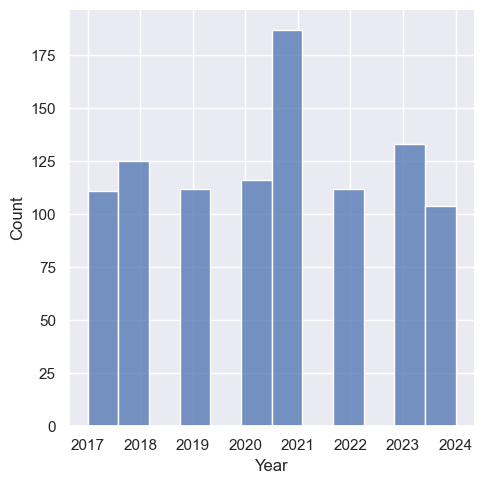

In [21]:
sns.displot(data_withno_mvs['Year'])
plt.show()

## Dealing with outliers

In [22]:
Q1 = data_withno_mvs['Price'].quantile(0.25)
Q3 = data_withno_mvs['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_1 = data_withno_mvs[(data_withno_mvs['Price'] >= lower_bound) &
                         (data_withno_mvs['Price'] <= upper_bound)]

In [23]:
data_1.describe()

,RAM,Storage,Processor_Speed,Screen_Size,Year,Price
count,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000
mean,15.550468,545.165453,3.092020,15.219979,2020.518210,1269.653767
std,11.220415,435.922593,0.617839,1.319231,2.206508,379.061951
min,4.000000,128.000000,2.000000,13.300000,2017.000000,480.000000
25%,8.000000,256.000000,2.560000,14.000000,2019.000000,986.840000
50%,16.000000,512.000000,3.094857,15.600000,2021.000000,1201.480000
75%,16.000000,512.000000,3.620000,16.000000,2022.000000,1508.500000
max,64.000000,2048.000000,4.200000,17.000000,2024.000000,2405.370000


In [24]:
data_cleaned = data_1.reset_index(drop=True)

## Checking the OLS assumptions

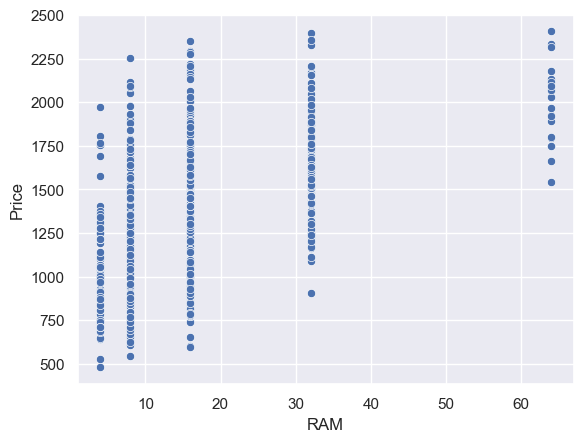

In [25]:
sns.scatterplot(x=data_cleaned['RAM'],y=data_cleaned['Price'])
plt.show()

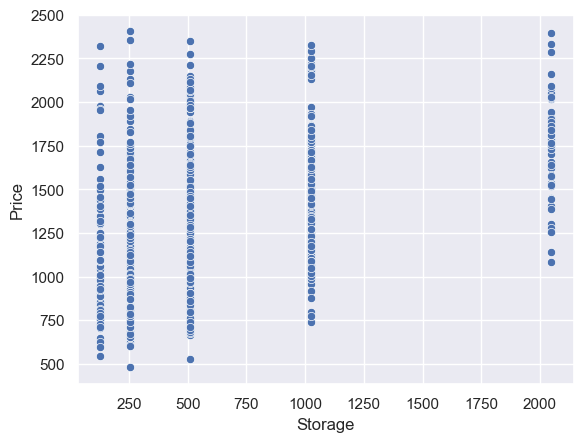

In [26]:
sns.scatterplot(x=data_cleaned['Storage'],y=data_cleaned['Price'])
plt.show()

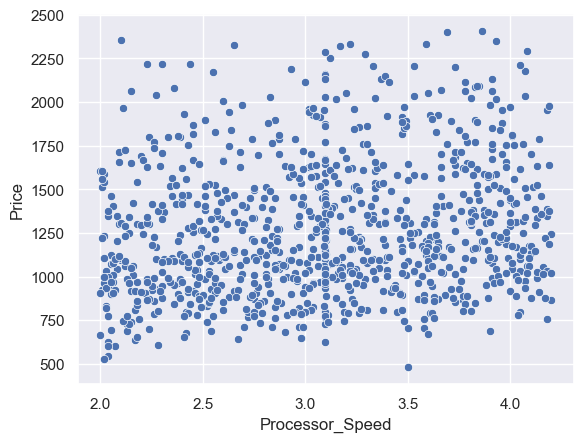

In [27]:
sns.scatterplot(x=data_cleaned['Processor_Speed'],y=data_cleaned['Price'])
plt.show()

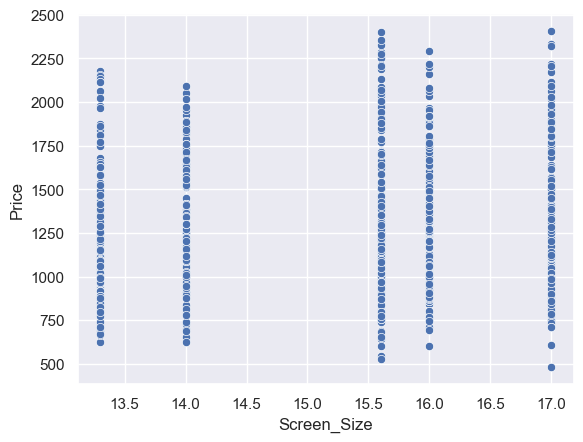

In [28]:
sns.scatterplot(x=data_cleaned['Screen_Size'],y=data_cleaned['Price'])
plt.show()

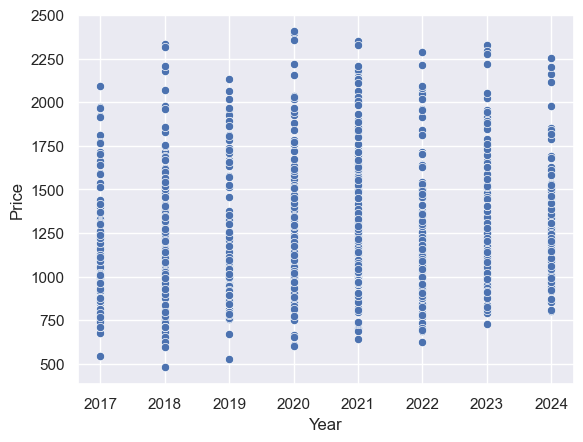

In [29]:
sns.scatterplot(x=data_cleaned['Year'],y=data_cleaned['Price'])
plt.show()

In [30]:
log_price = np.log(data_cleaned['Price'])
data_cleaned['log_price'] = log_price
data_cleaned

,Brand,RAM,Storage,Processor_Speed,Screen_Size,Condition,Year,Price,log_price
0,MSI,16.0,256.0,3.720000,17.0,New,2019.0,1337.45,7.198520
1,Asus,16.0,512.0,2.050000,14.0,Used,2022.0,922.01,6.826556
2,Acer,4.0,2048.0,3.360000,14.0,Used,2020.0,1301.30,7.171119
3,MSI,8.0,256.0,2.810000,15.6,New,2020.0,1014.26,6.921915
4,Samsung,16.0,1024.0,3.500000,13.3,New,2021.0,1644.02,7.404900
...,...,...,...,...,...,...,...,...,...
956,Samsung,4.0,256.0,2.960000,17.0,New,2023.0,986.07,6.893727
957,HP,8.0,256.0,3.094857,16.0,New,2022.0,957.77,6.864608
958,MSI,8.0,1024.0,2.130000,15.6,Used,2017.0,771.57,6.648427
959,HP,16.0,128.0,3.440000,15.6,New,2018.0,931.34,6.836624


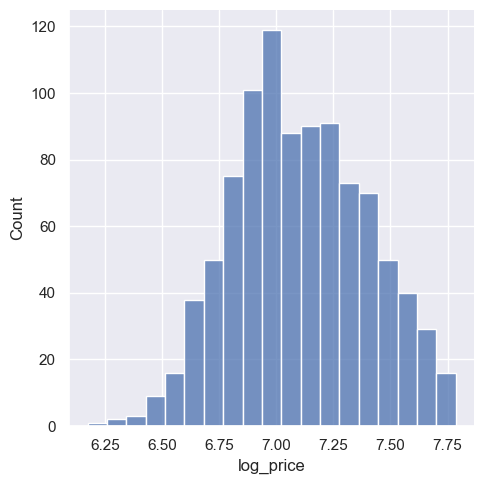

In [31]:
sns.displot(data_cleaned['log_price'])
plt.show()

In [32]:
data_cleaned = data_cleaned.drop(['Price'],axis=1)

## Multicollinearity

In [33]:
data_cleaned.columns.values

array(['Brand', 'RAM', 'Storage', 'Processor_Speed', 'Screen_Size',
       'Condition', 'Year', 'log_price'], dtype=object)

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['RAM','Year','Storage','Processor_Speed','Screen_Size']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns

In [35]:
vif

,VIF,features
0,2.928898,RAM
1,160.082428,Year
2,2.574697,Storage
3,26.162514,Processor_Speed
4,134.584069,Screen_Size


In [36]:
data_no_multicollinearity = data_cleaned.drop('Year',axis=1)

In [37]:
variables = data_no_multicollinearity[['RAM','Storage','Processor_Speed','Screen_Size']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns

In [38]:
vif

,VIF,features
0,2.872513,RAM
1,2.559551,Storage
2,22.728744,Processor_Speed
3,24.194105,Screen_Size


In [39]:
data_no_multicollinearity=data_no_multicollinearity.drop('Screen_Size',axis=1)

In [40]:
variables = data_no_multicollinearity[['RAM','Storage','Processor_Speed']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns

In [41]:
vif

,VIF,features
0,2.746506,RAM
1,2.482387,Storage
2,4.150968,Processor_Speed


## Create dummy variables

In [42]:
data_with_dummies = pd.get_dummies(data_no_multicollinearity, drop_first=True)

In [43]:
data_with_dummies.head()

,RAM,Storage,Processor_Speed,log_price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Samsung,Condition_Refurbished,Condition_Used
0,16.0,256.0,3.72,7.198520,0,0,0,0,0,1,0,0,0
1,16.0,512.0,2.05,6.826556,0,1,0,0,0,0,0,0,1
2,4.0,2048.0,3.36,7.171119,0,0,0,0,0,0,0,0,1
3,8.0,256.0,2.81,6.921915,0,0,0,0,0,1,0,0,0
4,16.0,1024.0,3.50,7.404900,0,0,0,0,0,0,1,0,0


In [44]:
data_with_dummies.columns.values

array(['RAM', 'Storage', 'Processor_Speed', 'log_price', 'Brand_Apple',
       'Brand_Asus', 'Brand_Dell', 'Brand_HP', 'Brand_Lenovo',
       'Brand_MSI', 'Brand_Samsung', 'Condition_Refurbished',
       'Condition_Used'], dtype=object)

In [45]:
cols_reordered=['RAM', 'Storage', 'Processor_Speed', 'Brand_Apple',
       'Brand_Asus', 'Brand_Dell', 'Brand_HP', 'Brand_Lenovo',
       'Brand_MSI', 'Brand_Samsung', 'Condition_Refurbished',
       'Condition_Used', 'log_price']

In [46]:
data_preprocessed = data_with_dummies[cols_reordered]

In [47]:
data_preprocessed.head()

,RAM,Storage,Processor_Speed,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Samsung,Condition_Refurbished,Condition_Used,log_price
0,16.0,256.0,3.72,0,0,0,0,0,1,0,0,0,7.198520
1,16.0,512.0,2.05,0,1,0,0,0,0,0,0,1,6.826556
2,4.0,2048.0,3.36,0,0,0,0,0,0,0,0,1,7.171119
3,8.0,256.0,2.81,0,0,0,0,0,1,0,0,0,6.921915
4,16.0,1024.0,3.50,0,0,0,0,0,0,1,0,0,7.404900


In [48]:
data_preprocessed.to_csv('data_preprocessed.csv')